# Principal Component Analysis (PCA)
### Theoretical and Experimental Study
Internship Project – NPOL, DRDO

## Motivation

High-dimensional data often contains redundancy and correlated features.
PCA helps reduce dimensionality by projecting data onto orthogonal directions
that maximize variance.

This notebook experimentally validates the mathematical principles
discussed in the internship report.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_diabetes, load_breast_cancer

## PCA on Diabetes Dataset
The dataset is standardized before applying PCA.

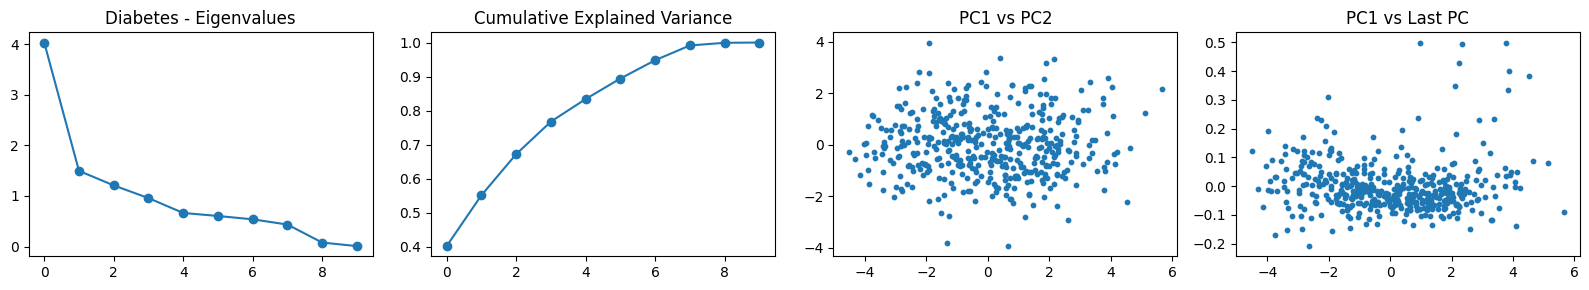

In [2]:
data = load_diabetes().data
data = StandardScaler().fit_transform(data)

pca = PCA(n_components=data.shape[1])
pca_result = pca.fit_transform(data)

eigenvalues = pca.explained_variance_
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axs = plt.subplots(1, 4, figsize=(16, 3))

axs[0].plot(eigenvalues, marker='o')
axs[0].set_title('Diabetes - Eigenvalues')

axs[1].plot(cum_var, marker='o')
axs[1].set_title('Cumulative Explained Variance')

axs[2].scatter(pca_result[:, 0], pca_result[:, 1], s=10)
axs[2].set_title('PC1 vs PC2')

axs[3].scatter(pca_result[:, 0], pca_result[:, -1], s=10)
axs[3].set_title('PC1 vs Last PC')

plt.tight_layout()
plt.show()

### Observations

- The first few principal components capture the majority of variance.
- Later components contribute minimal variance.
- This confirms the variance maximization principle of PCA.

## PCA on Breast Cancer Dataset

The Breast Cancer dataset contains 30 features describing tumor characteristics.
PCA is applied to examine how much variance can be captured in lower dimensions
and whether class separability is preserved in principal component space.

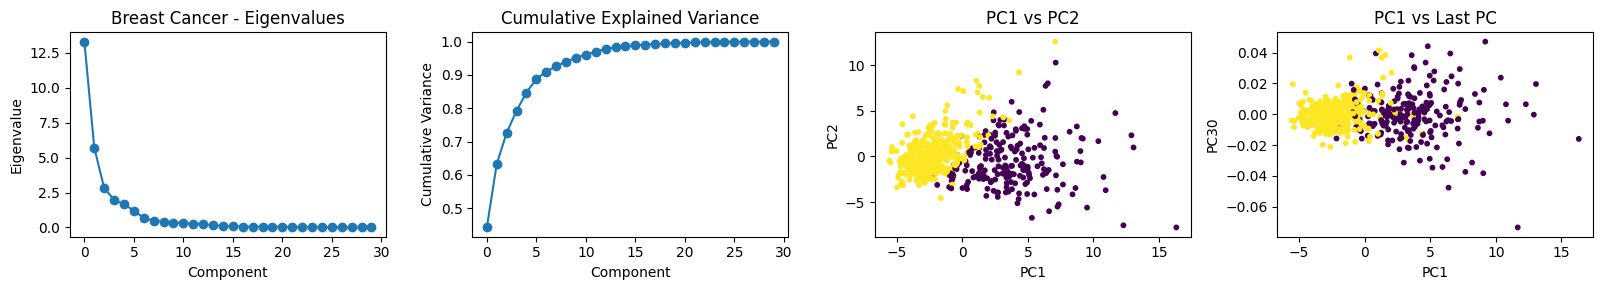

In [3]:
breast = load_breast_cancer()
data = breast.data
target = breast.target


scaler = StandardScaler()
data_scaled = scaler.fit_transform(data)


pca = PCA(n_components=data_scaled.shape[1])
pca_result = pca.fit_transform(data_scaled)


eigenvalues = pca.explained_variance_
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axs = plt.subplots(1, 4, figsize=(16, 3))


axs[0].plot(eigenvalues, marker='o')
axs[0].set_title('Breast Cancer - Eigenvalues')
axs[0].set_xlabel('Component')
axs[0].set_ylabel('Eigenvalue')


axs[1].plot(cum_var, marker='o')
axs[1].set_title('Cumulative Explained Variance')
axs[1].set_xlabel('Component')
axs[1].set_ylabel('Cumulative Variance')


axs[2].scatter(pca_result[:, 0], pca_result[:, 1], c=target, s=10)
axs[2].set_title('PC1 vs PC2')
axs[2].set_xlabel('PC1')
axs[2].set_ylabel('PC2')


axs[3].scatter(pca_result[:, 0], pca_result[:, -1], c=target, s=10)
axs[3].set_title('PC1 vs Last PC')
axs[3].set_xlabel('PC1')
axs[3].set_ylabel(f'PC{data_scaled.shape[1]}')

plt.tight_layout()
plt.show()

## Conceptual Takeaways

- PCA transforms correlated features into orthogonal components.
- Eigenvalues correspond to variance captured.
- Dimensionality reduction preserves structure while filtering noise.
- PCA assumes linear structure and may fail for nonlinear manifolds.